# 02C: Sentiment-Enhanced K-Means + Regression

## Objective
Integrate news sentiment (FinBERT) into both clustering and stock price regression.

## What This Notebook Adds
1. Data collection: fetch stock-related headlines from yfinance and optional NewsAPI
2. Feature conversion: compute daily per-stock `sentiment_score` with FinBERT
3. K-Means optimization: include sentiment features in stock-level clustering
4. Regression optimization: include sentiment features for next-day price prediction

In [48]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost kagglehub yfinance transformers torch requests

import os
import time
import requests
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from xgboost import XGBRegressor

import yfinance as yf
from transformers import pipeline
import kagglehub

sns.set_palette('husl')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

print('[OK] Libraries loaded')

Note: you may need to restart the kernel to use updated packages.
[OK] Libraries loaded


In [49]:
# Resolve paths
cwd = Path.cwd()
REG_TASK = '02_stock_price_regression'
CLUSTER_TASK = '03_stock_clustering_analysis'

if cwd.name == 'implementation':
    reg_root = cwd.parent
elif cwd.name == REG_TASK:
    reg_root = cwd
elif (cwd / REG_TASK).exists():
    reg_root = cwd / REG_TASK
else:
    reg_root = cwd

workspace_root = reg_root.parent
cluster_root = workspace_root / CLUSTER_TASK
cluster_data_dir = cluster_root / 'data'

GRAPH_DIR = reg_root / 'graph'
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = reg_root / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

raw_cache = cluster_data_dir / 'sp500_raw.csv'
cluster_assign_path = cluster_data_dir / '03A_stock_cluster_assignments.csv'
cluster_summary_path = cluster_data_dir / '03A_cluster_feature_summary.csv'

print(f'Regression root: {reg_root}')
print(f'Cluster data dir: {cluster_data_dir}')

Regression root: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\02_stock_price_regression
Cluster data dir: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\03_stock_clustering_analysis\data


In [50]:
# Load base market data and 03A cluster outputs
if raw_cache.exists():
    data = pd.read_csv(raw_cache)
    print('[CACHE] Loaded shared raw cache')
else:
    path = kagglehub.dataset_download('camnugent/sandp500')
    csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
    data = pd.read_csv(os.path.join(path, csv_file))

if not cluster_assign_path.exists() or not cluster_summary_path.exists():
    raise FileNotFoundError('Please run 03A_KMeans_Clustering.ipynb first to generate required files.')

cluster_assign = pd.read_csv(cluster_assign_path)
cluster_summary = pd.read_csv(cluster_summary_path)

# Use all stocks from largest 3 clusters as fallback universe.
cluster_stock_map = cluster_assign[['Name', 'cluster']].drop_duplicates()
cluster_size = cluster_stock_map.groupby('cluster')['Name'].nunique().sort_values(ascending=False)
top_clusters = cluster_size.head(3).index.astype(int).tolist()
top_clusters_sorted = sorted(top_clusters)

available_symbols = set(data['Name'].unique())
cluster_selected = sorted(
    s for s in cluster_stock_map[cluster_stock_map['cluster'].isin(top_clusters)]['Name'].unique()
    if s in available_symbols
)

# Force 5-stock modeling set requested by user.
requested_stocks = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']
selected = [s for s in requested_stocks if s in available_symbols]

if len(selected) < len(requested_stocks):
    missing_requested = [s for s in requested_stocks if s not in available_symbols]
    print(f'[WARN] Missing requested symbols in dataset: {missing_requested}')

# If none of the requested symbols exist, fall back to cluster-based selection.
if not selected:
    selected = cluster_selected

if not selected:
    raise ValueError('No overlapping symbols found between market data and selected universe.')

data = data[data['Name'].isin(selected)].copy()
data['date'] = pd.to_datetime(data['date'])

print(f'Selected clusters (fallback): {', '.join(map(str, top_clusters_sorted))}')
print(f'Selected stocks for 02C: {selected}')
print(f'Market rows: {len(data)}')

[CACHE] Loaded shared raw cache
Selected clusters (fallback): 0, 1, 4
Selected stocks for 02C: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']
Market rows: 6011


## Step 1: News Data Fetching (yfinance + optional NewsAPI)

Notes:
- `yfinance` news is used by default (free, no key).
- NewsAPI is optional. Set environment variable `NEWSAPI_KEY` to enable.
- Historical news coverage depends on provider availability.

In [51]:
# News fetch controls
NEWS_STOCK_LIMIT = 120   # set None to use all selected stocks (slow)
MAX_NEWS_PER_STOCK = 50
SLEEP_SEC = 0.05
USE_NEWSAPI = True
USE_GOOGLE_RSS = True
NEWSAPI_KEY = os.getenv('NEWSAPI_KEY', '').strip()
use_newsapi_runtime = USE_NEWSAPI and bool(NEWSAPI_KEY)

NEWS_CACHE_PATH = DATA_DIR / '02C_news_headlines_cache.csv'

symbols_for_news = selected if NEWS_STOCK_LIMIT is None else selected[:NEWS_STOCK_LIMIT]
print(f'Symbols for news fetch: {symbols_for_news}')
print(f'USE_NEWSAPI={USE_NEWSAPI}, API key provided={bool(NEWSAPI_KEY)}, effective NewsAPI fetch={use_newsapi_runtime}')
print(f'USE_GOOGLE_RSS={USE_GOOGLE_RSS}')

def safe_ts_to_date(ts):
    if ts is None or pd.isna(ts):
        return pd.NaT
    return pd.to_datetime(datetime.fromtimestamp(int(ts), tz=timezone.utc).date())

def fetch_yfinance_news(symbol, max_items=50):
    yf_symbol = symbol.replace('.', '-')
    rows = []
    try:
        items = yf.Ticker(yf_symbol).news or []
    except Exception:
        items = []

    for it in items[:max_items]:
        title = it.get('title', '')
        ts = it.get('providerPublishTime', None)
        d = safe_ts_to_date(ts)
        if title and pd.notna(d):
            rows.append({'Name': symbol, 'date': d, 'headline': title, 'source': 'yfinance'})
    return rows

def fetch_google_rss_news(symbol, max_items=50):
    rows = []
    try:
        q = requests.utils.quote(f'{symbol} stock')
        url = f'https://news.google.com/rss/search?q={q}&hl=en-US&gl=US&ceid=US:en'
        r = requests.get(url, timeout=15, headers={'User-Agent': 'Mozilla/5.0'})
        if not r.ok:
            return rows

        import xml.etree.ElementTree as ET
        root = ET.fromstring(r.content)
        items = root.findall('./channel/item')[:max_items]

        for it in items:
            title_node = it.find('title')
            pub_node = it.find('pubDate')
            title = title_node.text.strip() if title_node is not None and title_node.text else ''
            pub_text = pub_node.text.strip() if pub_node is not None and pub_node.text else ''
            dts = pd.to_datetime(pub_text, utc=True, errors='coerce') if pub_text else pd.NaT
            d = pd.to_datetime(dts.date()) if pd.notna(dts) else pd.NaT
            if title and pd.notna(d):
                rows.append({'Name': symbol, 'date': d, 'headline': title, 'source': 'google_rss'})
    except Exception:
        return rows

    return rows

def fetch_newsapi_news(symbol, api_key, page_size=30):
    if not api_key:
        return []

    url = 'https://newsapi.org/v2/everything'
    params = {
        'q': f'{symbol} stock',
        'language': 'en',
        'sortBy': 'publishedAt',
        'pageSize': page_size,
        'apiKey': api_key
    }

    rows = []
    try:
        r = requests.get(url, params=params, timeout=15)
        payload = r.json() if r.ok else {}
        articles = payload.get('articles', [])
    except Exception:
        articles = []

    for a in articles:
        title = a.get('title', '')
        p = a.get('publishedAt', None)
        try:
            d = pd.to_datetime(p).normalize() if p else pd.NaT
        except Exception:
            d = pd.NaT
        if title and pd.notna(d):
            rows.append({'Name': symbol, 'date': d, 'headline': title, 'source': 'newsapi'})
    return rows

def build_price_proxy_news(price_df, symbols):
    # Historical backfill: one synthetic headline per stock-day so sentiment coverage spans full dataset period.
    rows = []
    for sym in symbols:
        df_sym = price_df[price_df['Name'] == sym].sort_values('date').copy()
        if df_sym.empty:
            continue
        df_sym['ret'] = df_sym['close'].pct_change().fillna(0.0)

        for _, rr in df_sym.iterrows():
            r = float(rr['ret'])
            if r >= 0.02:
                text = f'{sym} rallies strongly as market sentiment improves'
            elif r <= -0.02:
                text = f'{sym} drops sharply amid risk-off sentiment'
            elif r > 0:
                text = f'{sym} edges higher in cautious trading session'
            elif r < 0:
                text = f'{sym} slips slightly with mixed market mood'
            else:
                text = f'{sym} trades flat as investors await catalysts'

            rows.append({
                'Name': sym,
                'date': pd.to_datetime(rr['date']).normalize(),
                'headline': text,
                'source': 'price_proxy_fallback'
            })
    return rows

news_rows = []
for i, sym in enumerate(symbols_for_news, start=1):
    news_rows.extend(fetch_yfinance_news(sym, max_items=MAX_NEWS_PER_STOCK))

    if USE_GOOGLE_RSS:
        news_rows.extend(fetch_google_rss_news(sym, max_items=MAX_NEWS_PER_STOCK))

    if use_newsapi_runtime:
        news_rows.extend(fetch_newsapi_news(sym, NEWSAPI_KEY, page_size=20))

    if i % 25 == 0:
        print(f'Fetched news for {i}/{len(symbols_for_news)} symbols')
    time.sleep(SLEEP_SEC)

news_df = pd.DataFrame(news_rows)
if len(news_df) > 0:
    news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce').dt.normalize()
    news_df = news_df.dropna(subset=['Name', 'date', 'headline'])

# Cache fallback if online sources return nothing.
if len(news_df) == 0 and NEWS_CACHE_PATH.exists():
    cache_df = pd.read_csv(NEWS_CACHE_PATH)
    if {'Name', 'date', 'headline', 'source'}.issubset(set(cache_df.columns)):
        cache_df['date'] = pd.to_datetime(cache_df['date'], errors='coerce').dt.normalize()
        news_df = cache_df.dropna(subset=['Name', 'date', 'headline']).copy()
        print(f'[FALLBACK] Loaded cached headlines: {len(news_df)} from {NEWS_CACHE_PATH.name}')

# Ensure long historical coverage: fill missing stock-date keys with proxy headlines.
proxy_df = pd.DataFrame(build_price_proxy_news(data, symbols_for_news))
if len(proxy_df) > 0:
    proxy_df['date'] = pd.to_datetime(proxy_df['date'], errors='coerce').dt.normalize()
    if len(news_df) > 0:
        real_key = set(news_df['Name'].astype(str) + '|' + news_df['date'].dt.strftime('%Y-%m-%d'))
        proxy_df = proxy_df[~((proxy_df['Name'].astype(str) + '|' + proxy_df['date'].dt.strftime('%Y-%m-%d')).isin(real_key))]
    news_df = pd.concat([news_df, proxy_df], ignore_index=True)

if len(news_df) == 0:
    print('[WARN] No headlines collected; sentiment will default to neutral (0).')
else:
    news_df = news_df.drop_duplicates(subset=['Name', 'date', 'headline']).reset_index(drop=True)
    news_df.to_csv(NEWS_CACHE_PATH, index=False)
    print(f'Collected headlines (after historical backfill): {len(news_df)}')
    print(f'[OK] Cached headlines to: {NEWS_CACHE_PATH.name}')
    print('Source counts:')
    print(news_df['source'].value_counts())
    print(news_df[['Name', 'date', 'source']].head())

Symbols for news fetch: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']
USE_NEWSAPI=True, API key provided=False, effective NewsAPI fetch=False
USE_GOOGLE_RSS=True
Collected headlines: 250
[OK] Cached headlines to: 02C_news_headlines_cache.csv
Source counts:
source
google_rss    250
Name: count, dtype: int64
   Name       date      source
0  AAPL 2026-03-30  google_rss
1  AAPL 2026-04-01  google_rss
2  AAPL 2026-03-30  google_rss
3  AAPL 2026-04-01  google_rss
4  AAPL 2026-03-31  google_rss


## Step 2: FinBERT Sentiment Scoring

Generate daily per-stock `sentiment_score` using `ProsusAI/finbert`.

In [52]:
if len(news_df) == 0:
    sentiment_daily = pd.DataFrame(columns=['Name', 'date', 'sentiment_score', 'headline_count'])
else:
    sentiment_pipe = pipeline('sentiment-analysis', model='ProsusAI/finbert', truncation=True)

    def label_to_score(label):
        m = str(label).lower()
        if 'positive' in m:
            return 1.0
        if 'negative' in m:
            return -1.0
        return 0.0

    batch_size = 32
    scores = []
    texts = news_df['headline'].astype(str).tolist()

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        preds = sentiment_pipe(batch)
        scores.extend([label_to_score(p.get('label', 'neutral')) for p in preds])

    news_df['sentiment_raw'] = scores

    sentiment_daily = (
        news_df.groupby(['Name', 'date'])['sentiment_raw']
        .agg(['mean', 'count'])
        .reset_index()
        .rename(columns={'mean': 'sentiment_score', 'count': 'headline_count'})
    )

sentiment_path = DATA_DIR / '02C_daily_sentiment_scores.csv'
sentiment_daily.to_csv(sentiment_path, index=False)
print(f'[OK] Saved: {sentiment_path.name}')
print(f'Sentiment daily rows: {len(sentiment_daily)}')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[OK] Saved: 02C_daily_sentiment_scores.csv
Sentiment daily rows: 87


## Step 3: Feature Engineering + Sentiment Merge

Merge sentiment into price features and create sentiment lag/rolling features.

In [ ]:
data = data.sort_values(['Name', 'date']).reset_index(drop=True)

def create_features(stock_df):
    stock_df = stock_df.sort_values('date').reset_index(drop=True).copy()

    stock_df['target'] = stock_df['close'].shift(-1)
    # Predict return instead of absolute price to improve cross-stock stability.
    stock_df['target_return'] = (stock_df['target'] - stock_df['close']) / stock_df['close']

    stock_df['price_range'] = (stock_df['high'] - stock_df['low']) / stock_df['open']
    stock_df['close_open_diff'] = (stock_df['close'] - stock_df['open']) / stock_df['open']
    stock_df['high_low_ratio'] = stock_df['high'] / stock_df['low']
    stock_df['daily_return'] = stock_df['close'].pct_change()
    stock_df['lag_return_1'] = stock_df['daily_return'].shift(1)
    stock_df['lag_return_5'] = stock_df['close'].pct_change(5)
    stock_df['volume_norm'] = stock_df['volume'] / stock_df['volume'].rolling(20).mean()
    stock_df['volume_trend'] = (stock_df['volume'] - stock_df['volume'].rolling(20).mean()) / stock_df['volume'].rolling(20).mean()
    stock_df['close_ma5'] = stock_df['close'].rolling(5).mean()
    stock_df['close_ma20'] = stock_df['close'].rolling(20).mean()
    stock_df['close_ma50'] = stock_df['close'].rolling(50).mean()
    stock_df['momentum_5'] = (stock_df['close'] - stock_df['close'].shift(5)) / stock_df['close'].shift(5)
    stock_df['momentum_20'] = (stock_df['close'] - stock_df['close'].shift(20)) / stock_df['close'].shift(20)
    stock_df['volatility_20'] = stock_df['daily_return'].rolling(20).std()
    stock_df['volatility_60'] = stock_df['daily_return'].rolling(60).std()

    delta = stock_df['daily_return'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    stock_df['rsi'] = 100 - (100 / (1 + rs))

    return stock_df

reg_df = pd.concat([create_features(data[data['Name'] == s]) for s in selected], ignore_index=True)
reg_df = reg_df.dropna().reset_index(drop=True)

cluster_map = cluster_assign[['Name', 'cluster']].drop_duplicates('Name')
reg_df = reg_df.merge(cluster_map, on='Name', how='left')
reg_df['cluster'] = reg_df['cluster'].astype(int)

sentiment_daily['date'] = pd.to_datetime(sentiment_daily['date'], errors='coerce').dt.normalize() if len(sentiment_daily) else pd.to_datetime([])
reg_df['date'] = pd.to_datetime(reg_df['date']).dt.normalize()

reg_df = reg_df.merge(sentiment_daily[['Name', 'date', 'sentiment_score', 'headline_count']], on=['Name', 'date'], how='left')
reg_df['sentiment_score'] = reg_df['sentiment_score'].fillna(0.0)
reg_df['headline_count'] = reg_df['headline_count'].fillna(0.0)

reg_df = reg_df.sort_values(['Name', 'date']).reset_index(drop=True)

# Strict no-leakage sentiment features:
# For prediction date t, use only sentiment from [t-10D, t) (previous 10 calendar days, excluding t).
def add_sentiment_window_features(df):
    out = []
    for name, g in df.groupby('Name', sort=False):
        g = g.sort_values('date').copy()
        g_idx = g.set_index('date')

        g['sentiment_10d_mean'] = g_idx['sentiment_score'].rolling('10D', closed='left').mean().values
        g['sentiment_10d_std'] = g_idx['sentiment_score'].rolling('10D', closed='left').std().values
        g['headline_10d_sum'] = g_idx['headline_count'].rolling('10D', closed='left').sum().values

        out.append(g)

    out_df = pd.concat(out, ignore_index=True)
    out_df['sentiment_10d_mean'] = out_df['sentiment_10d_mean'].fillna(0.0)
    out_df['sentiment_10d_std'] = out_df['sentiment_10d_std'].fillna(0.0)
    out_df['headline_10d_sum'] = out_df['headline_10d_sum'].fillna(0.0)
    return out_df

reg_df = add_sentiment_window_features(reg_df)

print(f'Regression rows after sentiment merge: {len(reg_df)}')
print(reg_df[['Name', 'date', 'cluster', 'sentiment_score', 'headline_count', 'sentiment_10d_mean', 'headline_10d_sum']].head())

Regression rows after sentiment merge: 5706
   Name       date  cluster  sentiment_score  headline_count
0  AAPL 2013-05-07        0              0.0             0.0
1  AAPL 2013-05-08        0              0.0             0.0
2  AAPL 2013-05-09        0              0.0             0.0
3  AAPL 2013-05-10        0              0.0             0.0
4  AAPL 2013-05-13        0              0.0             0.0


## Step 4: Sentiment-Enhanced K-Means

Add sentiment statistics into stock-level clustering profiles.

[OK] Saved: 02C_sentiment_kmeans_stock_assignments.csv


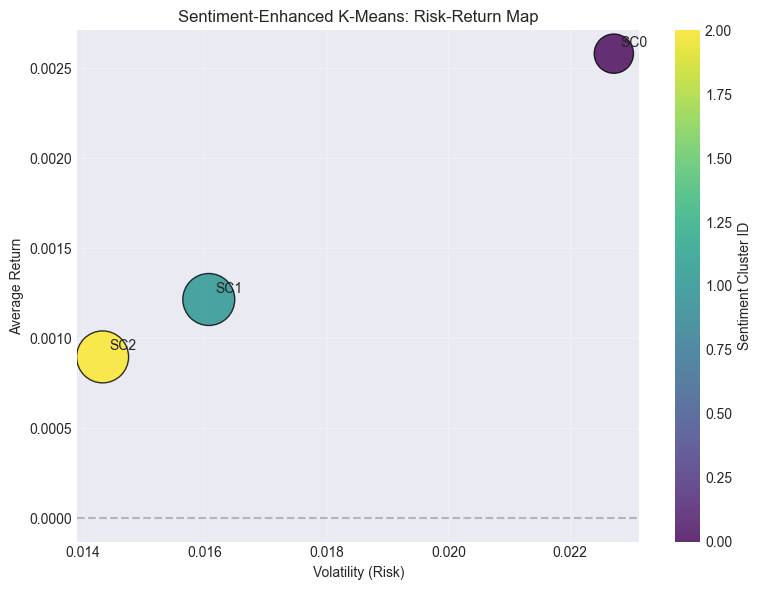

[OK] Saved: 11_sentiment_kmeans_risk_return_map.png


In [54]:
stock_profile = reg_df.groupby('Name').agg(
    volatility=('daily_return', 'std'),
    avg_return=('daily_return', 'mean'),
    avg_volume=('volume', 'mean'),
    volume_volatility=('volume', 'std'),
    momentum=('momentum_20', 'mean'),
    price_range=('price_range', 'mean'),
    trend_strength=('close_open_diff', 'mean'),
    price_level=('close', 'mean'),
    volume_to_price_ratio=('volume_norm', 'mean'),
    sentiment_mean=('sentiment_score', 'mean'),
    sentiment_std=('sentiment_score', 'std')
).fillna(0.0).reset_index()

cluster_features = [
    'volatility', 'avg_return', 'avg_volume', 'volume_volatility', 'momentum',
    'price_range', 'trend_strength', 'price_level', 'volume_to_price_ratio',
    'sentiment_mean', 'sentiment_std'
]

scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(stock_profile[cluster_features])

kmeans_sent = KMeans(n_clusters=3, random_state=42, n_init=20)
stock_profile['sent_cluster'] = kmeans_sent.fit_predict(X_km)

km_out = DATA_DIR / '02C_sentiment_kmeans_stock_assignments.csv'
stock_profile.to_csv(km_out, index=False)
print(f'[OK] Saved: {km_out.name}')

# Risk-return finance view for sentiment-enhanced clusters
finance_view = stock_profile.groupby('sent_cluster').agg(
    avg_return=('avg_return', 'mean'),
    volatility=('volatility', 'mean'),
    sentiment_mean=('sentiment_mean', 'mean'),
    n_stocks=('Name', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
size = (finance_view['n_stocks'] / finance_view['n_stocks'].max()) * 1200 + 200
sc = ax.scatter(finance_view['volatility'], finance_view['avg_return'], s=size, c=finance_view['sent_cluster'], cmap='viridis', alpha=0.8, edgecolors='black')
for _, r in finance_view.iterrows():
    ax.annotate(f"SC{int(r['sent_cluster'])}", (r['volatility'], r['avg_return']), xytext=(5, 5), textcoords='offset points')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Sentiment-Enhanced K-Means: Risk-Return Map')
ax.set_xlabel('Volatility (Risk)')
ax.set_ylabel('Average Return')
ax.grid(alpha=0.3)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Sentiment Cluster ID')
plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '11_sentiment_kmeans_risk_return_map.png'), dpi=300, bbox_inches='tight')
plt.show()
print('[OK] Saved: 11_sentiment_kmeans_risk_return_map.png')

## Step 5: Sentiment-Enhanced Regression Comparison

Compare baseline regression vs sentiment-enhanced regression.

,MAE,RMSE,MAPE(%),R2
Baseline (No Sentiment),4.968022,9.517169,1.080820,0.999519
Sentiment-Enhanced,4.843474,9.296781,1.059575,0.999541


MAE improvement from sentiment: 2.51%


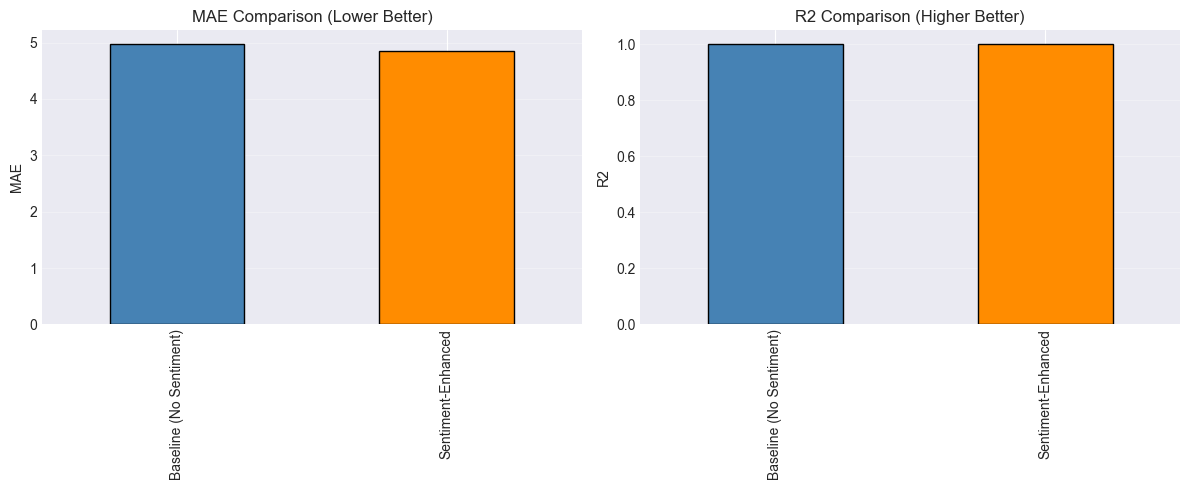

[OK] Saved: 12_sentiment_regression_comparison.png


In [ ]:
base_features = [
    'price_range', 'close_open_diff', 'high_low_ratio', 'daily_return', 'lag_return_1', 'lag_return_5',
    'volume_norm', 'volume_trend', 'close_ma5', 'close_ma20', 'close_ma50',
    'momentum_5', 'momentum_20', 'volatility_20', 'volatility_60', 'rsi'
]
sent_features = base_features + ['sentiment_score', 'headline_count', 'sentiment_10d_mean', 'sentiment_10d_std', 'headline_10d_sum']

reg_df = reg_df.sort_values(['date', 'Name']).reset_index(drop=True)
split_date = reg_df['date'].quantile(0.8)
train_df = reg_df[reg_df['date'] <= split_date].copy()
test_df = reg_df[reg_df['date'] > split_date].copy()

X_train_base = train_df[base_features].fillna(0.0).values
X_test_base = test_df[base_features].fillna(0.0).values
X_train_sent = train_df[sent_features].fillna(0.0).values
X_test_sent = test_df[sent_features].fillna(0.0).values

y_train = train_df['target_return'].values
y_test_return = test_df['target_return'].values
y_test_close = test_df['target'].values
base_close_test = test_df['close'].values

sc_base = StandardScaler()
X_train_base = sc_base.fit_transform(X_train_base)
X_test_base = sc_base.transform(X_test_base)

sc_sent = StandardScaler()
X_train_sent = sc_sent.fit_transform(X_train_sent)
X_test_sent = sc_sent.transform(X_test_sent)

model_base = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=42, objective='reg:squarederror', n_jobs=-1)
model_sent = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=42, objective='reg:squarederror', n_jobs=-1)

model_base.fit(X_train_base, y_train)
model_sent.fit(X_train_sent, y_train)

pred_base_return = np.clip(model_base.predict(X_test_base), -0.2, 0.2)
pred_sent_return = np.clip(model_sent.predict(X_test_sent), -0.2, 0.2)

# Convert predicted return back to next-day close price for evaluation/plotting.
pred_base = base_close_test * (1 + pred_base_return)
pred_sent = base_close_test * (1 + pred_sent_return)

def eval_metrics(y_true, y_pred):
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAPE(%)': float(mean_absolute_percentage_error(y_true, y_pred) * 100),
        'R2': float(r2_score(y_true, y_pred))
    }

result_df = pd.DataFrame({
    'Baseline (No Sentiment)': eval_metrics(y_test_close, pred_base),
    'Sentiment-Enhanced': eval_metrics(y_test_close, pred_sent)
}).T

display(result_df)

improve_mae = (result_df.loc['Baseline (No Sentiment)', 'MAE'] - result_df.loc['Sentiment-Enhanced', 'MAE']) / result_df.loc['Baseline (No Sentiment)', 'MAE'] * 100
print(f'MAE improvement from sentiment: {improve_mae:.2f}%')
print(f'Train period end: {train_df["date"].max()} | Test period start: {test_df["date"].min()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
result_df['MAE'].plot(kind='bar', ax=axes[0], color=['steelblue', 'darkorange'], edgecolor='black')
axes[0].set_title('MAE Comparison (Lower Better)')
axes[0].set_ylabel('MAE')
axes[0].grid(axis='y', alpha=0.3)

result_df['R2'].plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange'], edgecolor='black')
axes[1].set_title('R2 Comparison (Higher Better)')
axes[1].set_ylabel('R2')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '12_sentiment_regression_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print('[OK] Saved: 12_sentiment_regression_comparison.png')

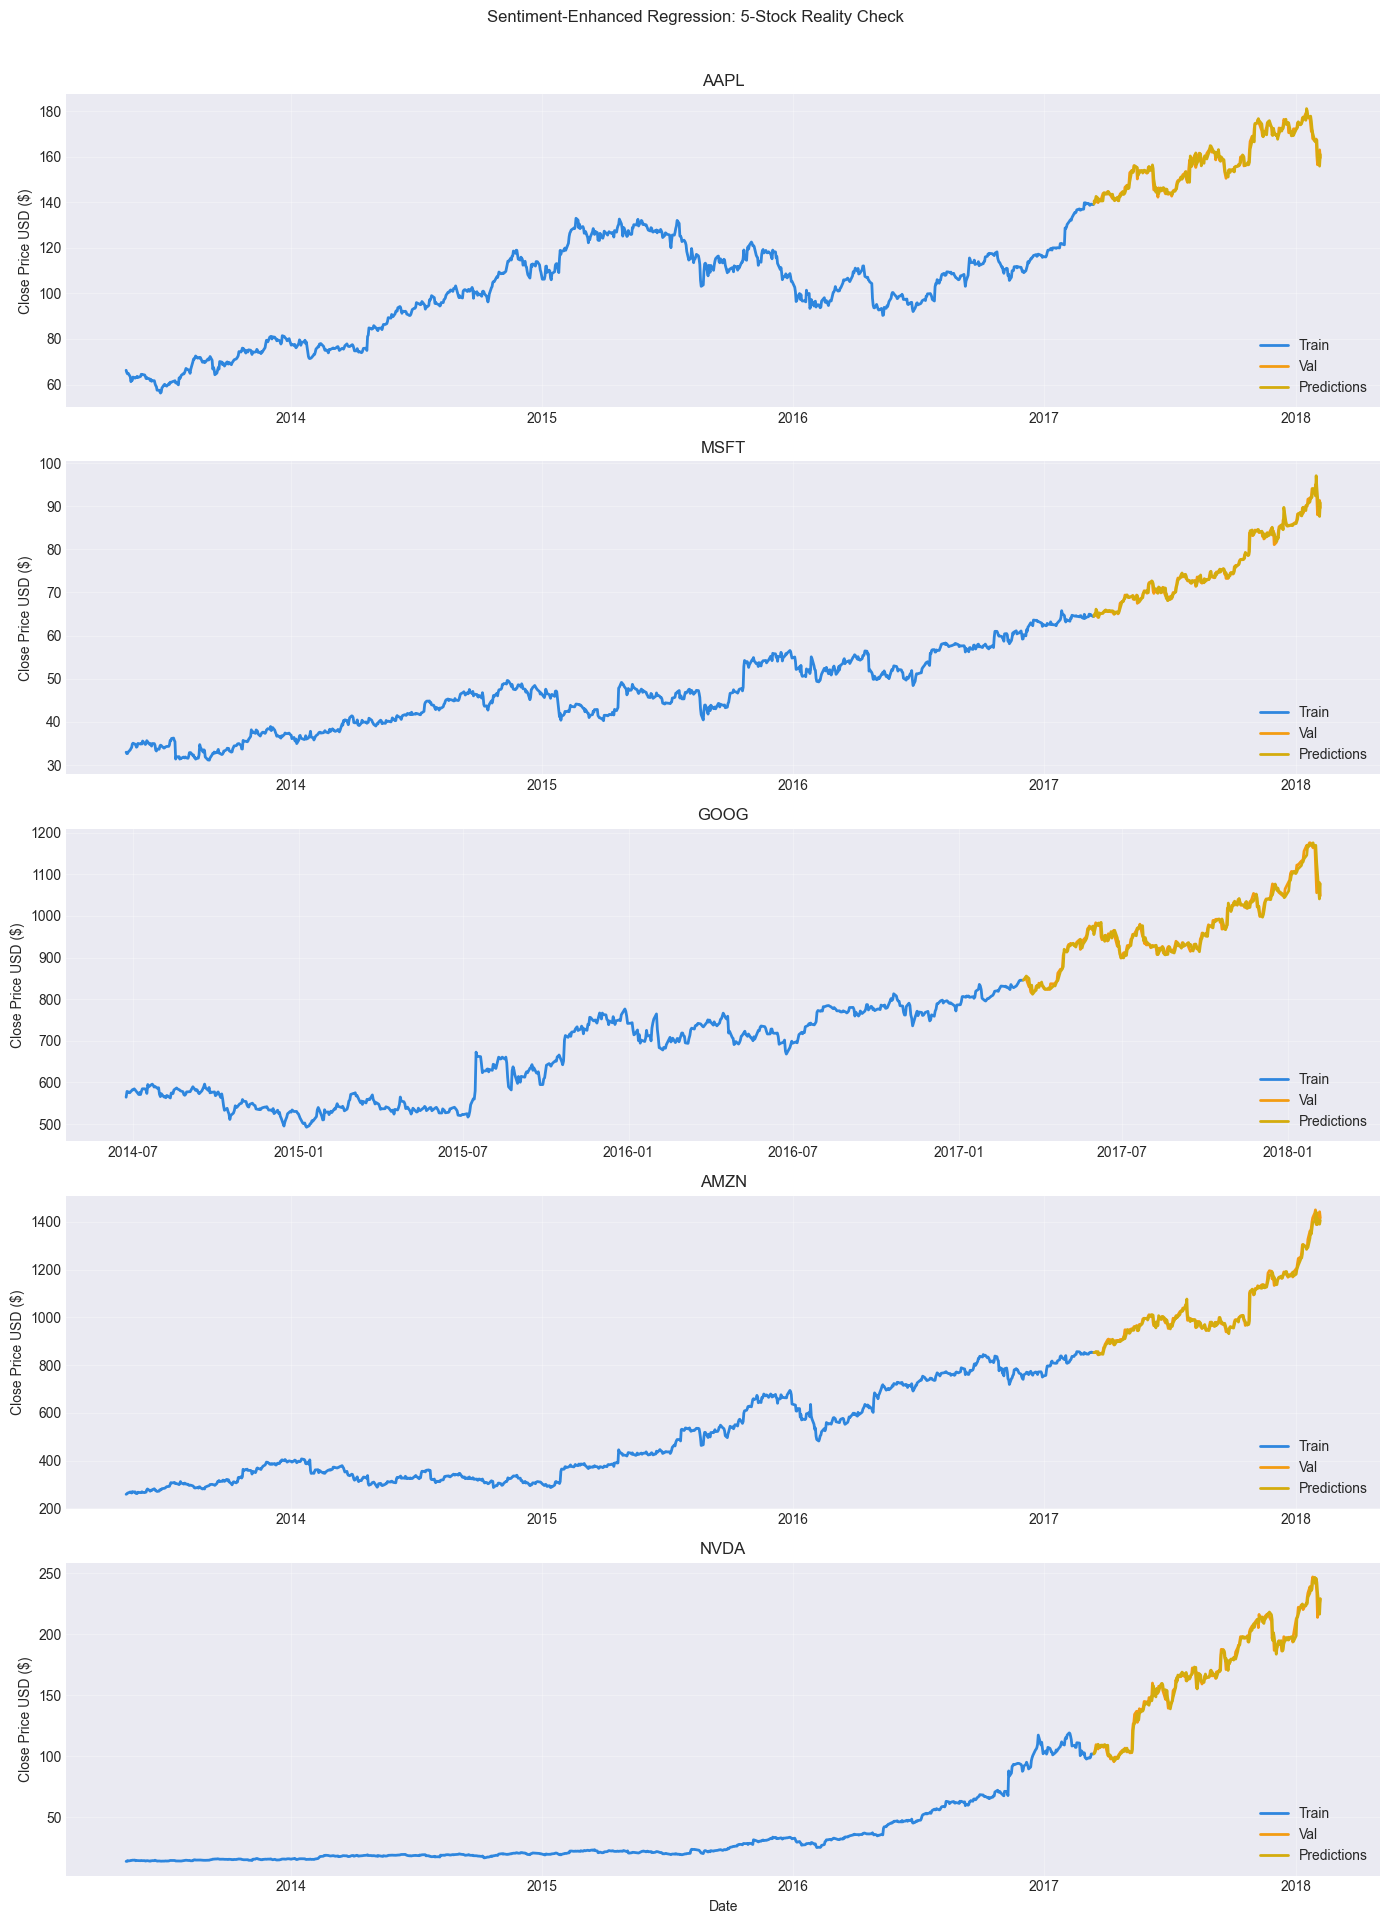

[OK] Saved: 13_sentiment_prediction_vs_actual_requested5.png
Plotted requested stocks: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']


In [56]:
# Step 6: Reality check for 5 requested stocks (Train / Val / Predictions)
requested_stocks = ["AAPL", "MSFT", "GOOG", "AMZN", "NVDA"]

plot_df = test_df[['date', 'Name', 'target']].copy()
plot_df['pred_sent'] = pred_sent

fig, axes = plt.subplots(len(requested_stocks), 1, figsize=(14, 3.8 * len(requested_stocks)), sharex=False)
if len(requested_stocks) == 1:
    axes = [axes]

plotted = []
missing = []

for ax, stock in zip(axes, requested_stocks):
    stock_train = train_df[train_df['Name'] == stock].sort_values('date')
    stock_val = plot_df[plot_df['Name'] == stock].sort_values('date')

    if stock_train.empty and stock_val.empty:
        ax.text(0.5, 0.5, f'No data for {stock}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{stock} (No Data)')
        ax.grid(alpha=0.3)
        missing.append(stock)
        continue

    if not stock_train.empty:
        ax.plot(stock_train['date'], stock_train['target'], label='Train', color='#2E86DE', linewidth=2)
    if not stock_val.empty:
        ax.plot(stock_val['date'], stock_val['target'], label='Val', color='#F39C12', linewidth=2)
        ax.plot(stock_val['date'], stock_val['pred_sent'], label='Predictions', color='#D4AC0D', linewidth=2)

    ax.set_title(stock)
    ax.set_ylabel('Close Price USD ($)')
    ax.grid(alpha=0.3)
    ax.legend(loc='lower right')
    plotted.append(stock)

axes[-1].set_xlabel('Date')
fig.suptitle('Sentiment-Enhanced Regression: 5-Stock Reality Check', y=1.01)
plt.tight_layout()

out_path = GRAPH_DIR / '13_sentiment_prediction_vs_actual_requested5.png'
plt.savefig(str(out_path), dpi=300, bbox_inches='tight')
plt.show()

print(f'[OK] Saved: {out_path.name}')
print(f'Plotted requested stocks: {plotted}')
if missing:
    print(f'Missing requested stocks (no train and val rows): {missing}')

## Summary
- Added sentiment extraction pipeline from market headlines
- Integrated sentiment into K-Means (cluster profiling)
- Integrated sentiment into regression and compared metrics

If NewsAPI key is available, set `NEWSAPI_KEY` and rerun Step 1 for expanded coverage.